# Ch 7. 模擬障礙物對緊急疏散效率的影響

在醫院或大型公共建築中，緊急事故（如火災、地震、煙霧外洩）發生時，如何有效率地疏散人群是重要課題。過去研究指出：在出口附近適度設置障礙物（如柱子、屏障）反而能減少瓶頸現象、提升疏散效率。本作業會使用粒子模型模擬人群疏散行為，並探討在不同障礙物配置、不同人群參數下，對疏散效率（完成疏散所需時間）的影響

1. 使用粒子模型模擬人群疏散情境
2. 比較不同參數（人數、速度、障礙物形狀與位置）對疏散效率的影響
3. 找出最佳的障礙物設置方案，並提供合理解釋
4. 完成一份具備資料、圖表與分析的報告

## Section 1. Data Ingestion & Geometry Definition

在進行連續空間模擬之前，首先需要先定義狀態空間 $\Omega$。其中疏散區域定義為一個二維歐幾里得子空間 $\Omega \subset \mathbb{R}^2$，空間的邊界由題目給定的 $x_{size}$ 與 $y_{exit}$ 決定。雖然物理模擬主要依賴連續座標，但首先要載入題目提供的資料集，來檢視資料集的拓樸結構是否能對應到需求的的幾何邊界，或者僅作為路徑規劃的圖

In [1]:
import pandas as pd
df_links = pd.read_csv('ch7_links.csv')
print(df_links.head())

  Unnamed: 0  Node0  Node1  Node2  Node3  Node4  Node5  Node6  Node7  Node8  \
0      Node0    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0   
1      Node1    0.0    0.0    0.0    0.0    0.0    1.0    0.0    0.0    0.0   
2      Node2    0.0    0.0    0.0    0.0    1.0    1.0    1.0    0.0    0.0   
3      Node3    0.0    0.0    0.0    0.0    0.0    0.0    0.0    1.0    0.0   
4      Node4    0.0    0.0    1.0    0.0    0.0    0.0    0.0    1.0    1.0   

   ...  Node10  Node11  Node12  Node13  Node14  Node15  Node16  Node17  \
0  ...     0.0     0.0     0.0     0.0     0.0     1.0     0.0     0.0   
1  ...     0.0     1.0     0.0     1.0     0.0     0.0     1.0     0.0   
2  ...     1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3  ...     0.0     0.0     0.0     0.0     0.0     1.0     0.0     0.0   
4  ...     1.0     0.0     0.0     0.0     0.0     1.0     0.0     0.0   

   Node18  Node19  
0     0.0     0.0  
1     0.0     0.0  
2     0.0     0.0  


In [2]:
df_route = pd.read_csv('ch7_route.csv')
print(df_route)

   1  1.1  1.2  1.3  0  0.1  1.4  1.5  1.6  1.7
0  1    1    1    1  0    0    1    1    1    1
1  1    1    1    1  1    1    1    1    1    1
2  1    1    1    1  1    1    1    1    1    1
3  1    1    1    1  1    1    1    1    1    1
4  1    1    1    1  1    1    1    1    1    1
5  0    0    0    0  0    0    1    1    1    1
6  0    0    0    0  0    0    1    1    1    1
7  0    0    0    0  0    0    1    1    1    1
8  0    0    0    0  0    0    1    1    1    1


## Section 2. Begin Simulation

### Step A. Social Force Model

首先檢視輸入資料的數學屬性。回顧電腦科學早期發展（如 1959 年 Dijkstra 或 1968 年 Hart 等人的 A* 演算法），人群移動常被建模為圖論問題。在數學上通常定義 Metric Graph $G = (V, E)$，其中狀態 $s$ 為離散節點 $s \in V$，狀態轉移則是瞬時或基於權重的跳躍 $s_t \to s_{t+1}$

原始論文：[Helbing, D., & Molnár, P. (1995). Social force model for pedestrian dynamics. *Physical Review E*, *51*(5), 4282–4286. https://doi.org/10.1103/PhysRevE.51.4282](https://doi.org/10.1103/PhysRevE.51.4282)

對應到這次作業的資料：

* **Adjacency Matrix ($A$)**：`df_links` 構成圖 $G$ 的鄰接矩陣（$|V|=20$），這適用於狀態空間有限的離散路徑規劃。
* **Occupancy Grid ($M$)**：`df_route` 呈現為 $9 \times 10$ 的二元矩陣 $M_{ij} \in \{0, 1\}$。觀察資料分佈可見左下角（Row 5-8, Col 0-3）存在明顯的 `0` 值區塊，這在網格地圖中代表障礙物或非行走區域。

然而，這類離散模型難以描述 **擁擠**、**推擠** 或 **慣性**，因為圖論中的節點 $v$ 通常缺乏「容量」限制，亦不具備模擬物理碰撞的條件。

Helbing & Molnár (1995) 提出的 Social Force Model（SFM）屬於基於牛頓力學的 **微觀動力系統**，將行人視為在連續的 Euclidean Space 中的 **自驅動粒子**，具有以下特性

1.  **連續相空間**：粒子狀態定義於 $(\mathbf{x}, \mathbf{v}) \in \mathbb{R}^4$，需要操作位勢場的梯度 $\nabla U(\mathbf{x})$。
2.  **模擬區域定義**：引入牛頓運動定律來描述行為，定義模擬區域 $\Omega$ 與邊界 $\partial \Omega$ 為：

    $$
    \Omega = \{ (x, y) \in \mathbb{R}^2 \mid 0 \le x \le x_{max}, 0 \le y \le y_{max} \}
    $$

    $$
    \partial \Omega = \{ (x, y) \in \mathbb{R}^2 \mid x = 0 \text{ or } x = x_{max} \text{ or } y = 0 \text{ or } y = y_{max} \}
    $$

因為本次作業重點在於 $\Omega \subset \mathbb{R}^2$ 的連續空間操作，粒子的位置向量 $\mathbf{x} \in \mathbb{R}^2$ 與速度向量 $\mathbf{v} \in \mathbb{R}^2$ 必須保持連續且可微分，以嚴格滿足牛頓運動定律。

因此，為了精確符合規範中的幾何要求（如 $x_{size}=8, y_{exit}=6$），就會建議直接操作 **解析幾何 (Analytical Geometry)** 的方式直接定義邊界條件，而非將離散網格 $M$ 強制拉伸進行映射（不然只有四方向或八方向）。這樣就可以在確保物理引擎的數值精度同時，也不會因為制約於網格解析度而降低

### Step B Geometry Definition

將模擬區域 $\Omega$ 定義為二維笛卡兒座標系中的一個閉區間：

$$
\Omega = [0, X_{SIZE}] \times [0, Y_{SIZE}] \subset \mathbb{R}^2
$$

其中 $X_{SIZE} = 8.0$，$Y_{SIZE} = 6.0$

In [3]:
X_SIZE = 8.0
Y_SIZE = 6.0
X_EXIT = X_SIZE / 2.0  # Center of the exit (x=4.0)
Y_EXIT = Y_SIZE        # Exit is at the top edge
EXIT_WIDTH = 1.0       # The gap size for agents to pass through

在這個區域的邊界 $\partial \Omega$ 上，可以施加了兩種物理條件：

1. **Reflecting / Repulsive Boundary** 即「牆壁」，因為粒子無法穿越且會受到斥力。範圍在 $x=0, x=X_{SIZE}, y=0$ 以及 $y=Y_{SIZE}$ 的非出口部分
2. **Absorbing Boundary** 即「出口」，粒子到達此處視為離開系統。位於 $y=Y_{SIZE}$ 的中間段

這樣就可以設定這些全域常數並做出一個 frame；而對於左、右、下三面牆可以視為幾何上的「實體障礙」。在視覺化中，可以用 `matplotlib.patches.Rectangle` 來畫出這些剛性邊界。這主要是用來定義物理引擎中的障礙物，同時可以做視覺呈現。要注意牆壁是有厚度的，所以定義一個厚度之後，左右邊界都會被一個厚度制約，需要扣除

### Step C. The Exit Discontinuity

頂部的牆壁 $y=Y_{SIZE}$ 比較特殊，因為這段包含出口，而出口就是透過把頂部牆壁切斷，留下一個寬度為 `EXIT_WIDTH` 的間隙。在數學中，這段牆壁可以看作是分段定義函數，而非連續函數

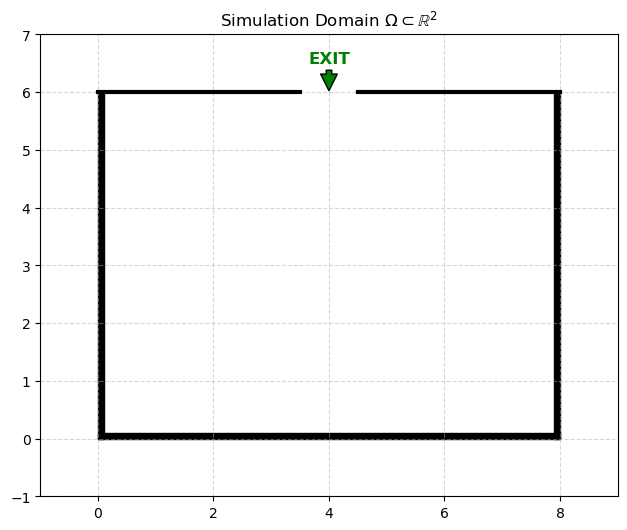

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 6))

# Step A.1
ax.set_xlim(-1, X_SIZE + 1)
ax.set_ylim(-1, Y_SIZE + 1)
ax.set_aspect('equal') # Ensure 1 unit in x equals 1 unit in y
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_title(r"Simulation Domain $\Omega \subset \mathbb{R}^2$")

# Step A.2
wall_thickness = 0.1
walls = [
    # Left Wall: x=0
    patches.Rectangle((0, 0), wall_thickness, Y_SIZE, color='k'),
    # Right Wall: x=8
    patches.Rectangle((X_SIZE - wall_thickness, 0), wall_thickness, Y_SIZE, color='k'),
    # Bottom Wall: y=0
    patches.Rectangle((0, 0), X_SIZE, wall_thickness, color='k')
]

# Step A.3
for wall in walls:
    ax.add_patch(wall)

ax.plot([0, X_EXIT - EXIT_WIDTH/2], [Y_SIZE, Y_SIZE], 'k', linewidth=3)

ax.plot([X_EXIT + EXIT_WIDTH/2, X_SIZE], [Y_SIZE, Y_SIZE], 'k', linewidth=3)

ax.annotate('EXIT', xy=(X_EXIT, Y_SIZE), xytext=(X_EXIT, Y_SIZE + 0.5),
            arrowprops=dict(facecolor='green', shrink=0.05),
            ha='center', fontsize=12, color='green', weight='bold')

plt.show()

### Step D. SFM Physics Engine Kernel in Vector Fields: Goal and Social Forces

#### Module 1: Stochastic Initialization

現在要在狀態空間 $\Omega$ 的左半部子集 $\Omega_{init}$ 中生成 $N$ 個點來模擬人與人之間的位置，但這不是單純的均勻分佈，因為人之間不能重疊。這在數學上是 Hard-Core Point Process，定義

1. 採樣空間 $\mathbf{x} \sim U(\Omega_{init})$，其中 $\Omega_{init} = [0.5, \frac{X_{max}}{2}-0.5] \times [0.5, Y_{max}-0.5]$
2. 對於任意兩點 $i, j$，必須滿足 **互斥條件** $\|\mathbf{x}_i - \mathbf{x}_j\|_2 \ge 2r$，其中 $r$ 是粒子半徑

但因為互斥條件存在，所以直接用公式產生座標可能會導致粒子重疊，所以要採用 Rejection Sampling。操作是

1. 隨機生成一個候選點 $\mathbf{x}_{cand}$
2. 計算候選點與已存在所有點集 $S$ 的距離 $d = \min_{p \in S} \|\mathbf{x}_{cand} - \mathbf{p}\|$
3. 若 $d < 2r$ 則拒絕該點加入集合 $S$；否則加入集合 $S$

令人數為 `num_agent`，則程式碼為

In [5]:
import numpy as np

def init_simulation(num_agents, x_limit, y_limit, seed=42):

    np.random.seed(seed)
    
    radius = 0.3
    pos = np.zeros((num_agents, 2))
    vel = np.zeros((num_agents, 2))
    
    count = 0
    max_attempts = num_agents * 1000 # just for safety break
    attempts = 0
    
    while count < num_agents and attempts < max_attempts:
        # 1. x in [0.5, 3.5], y in [0.5, 5.5] given x_limit=8, y_limit=6
        x_cand = np.random.uniform(0.5, x_limit/2 - 0.5) # 3.
        y_cand = np.random.uniform(0.5, y_limit - 0.5) # 3.
        candidate = np.array([x_cand, y_cand])
        
        if count > 0:
            # 2. Vectorized distance calculation: ||x_cand - x_existing||
            existing_agents = pos[:count]
            dists = np.linalg.norm(existing_agents - candidate, axis=1)
            
            if np.min(dists) < 2 * radius:
                attempts += 1
                continue # 3. Reject
        
        # 3. Accept
        pos[count] = candidate
        count += 1
        
    return pos, vel

每個粒子 $i$ 受到的合力 $\mathbf{F}_i$ 是三個向量場的疊加：

$$
\mathbf{F}_i = \mathbf{F}_{goal} + \mathbf{F}_{social} + \mathbf{F}_{obs}
$$

#### Module 2: Goal Force $\mathbf{F}_{goal}$

粒子希望以期望速度 $v_d$ 沿著方向 $\mathbf{e}_i^0$ 移動，但慣性使其保持當前速度 $\mathbf{v}_i$

$$
\mathbf{F}_{goal, i} = \frac{v_d \mathbf{e}_i^0 - \mathbf{v}_i}{\tau}, \quad \mathbf{e}_i^0 = \frac{\mathbf{x}_{exit} - \mathbf{x}_i}{\|\mathbf{x}_{exit} - \mathbf{x}_i\|}
$$

其中 $\mathbf{e}_i^0$ 是指向出口的單位向量，$\tau$ 是時間常數

In [6]:
def compute_goal_force(pos, vel, params):
    goal = params['exit_pos']
    v_des = params['v_desired']
    tau = params['tau']
    
    # Direction vector
    diff = goal - pos
    dist = np.linalg.norm(diff, axis=1, keepdims=True)
    e_goal = diff / (dist + 1e-6)
    
    # Force calculation
    f_goal = (v_des * e_goal - vel) / tau
    return f_goal

#### Module 3: Social Force $\mathbf{F}_{social}$

這是基於距離的指數斥力場

$$
\mathbf{F}_{ij} = A \cdot \exp\left(\frac{2r - d_{ij}}{B}\right) \cdot \mathbf{n}_{ij}, \quad \mathbf{n}_{ij} = \frac{\mathbf{x}_i - \mathbf{x}_j}{d_{ij}}
$$

其中 $\mathbf{n}_{ij}$ 是由 $j$ 指向 $i$ 的斥力方向

但因為這屬於成對交互作用，在計算這種力的時候，需要考慮所有成對的斥力。因此

$$
\forall (i, j), \quad \mathbf{F}_{social, i} = \sum_{j \neq i} A_p \exp\left(\frac{r_{ij} - d_{ij}}{B_p}\right) \mathbf{n}_{ij}
$$


In [7]:
def compute_social_force(pos, params):

    N = pos.shape[0]
    forces = np.zeros((N, 2))
    
    radius = params['radius']
    A_p = params['A_p']
    B_p = params['B_p']
    
    # Pairwise computation
    for i in range(N):
        for j in range(i + 1, N):
            delta = pos[i] - pos[j]
            d_ij = np.linalg.norm(delta)
            n_ij = delta / (d_ij + 1e-6)
            
            # Repulsion strength: r_ij = 2 * radius
            val = A_p * np.exp((2 * radius - d_ij) / B_p)
            f_vec = val * n_ij
            
            # Action-Reaction
            forces[i] += f_vec
            forces[j] -= f_vec
            
    return forces

### Step E. SFM Physics Engine Kernel in Vector Fields: All Static Obstacles

定義集合 $W$ 為所有靜態物體的集合：

- $W_{boundaries}$ 用來模擬區域的四面牆做為邊界
- $W_{internal}$ 是人工放置的圓形或矩形障礙物

根據疊加原理，環境總斥力 $\mathbf{F}_{obs}$ (或程式碼中的 f_wall_total) 是所有 $w \in W$ 產生的斥力總和：

$$
\mathbf{F}_{obs} = \sum_{w \in W} \mathbf{F}_{iw} = \underbrace{\sum_{b \in W_{boundaries}} \mathbf{F}_{ib}}_{\text{f\_boundaries}} + \underbrace{\sum_{o \in W_{internal}} \mathbf{F}_{io}}_{\text{f\_obstacles}}
$$

所以這邊就需要拆開處理：

1. 數學上，若將每個障礙物 $w \in W$ 視為一個產生排斥位勢場 $U_w(\mathbf{x})$ 的源。粒子 $i$ 在位置 $\mathbf{x}_i$ 受到該場的作用力 $\mathbf{F}_{iw}$ 定義為該位勢的負梯度：

    $$
    \mathbf{F}_{iw}(\mathbf{x}_i) = - \nabla U_w(\mathbf{x}_i)
    $$

2. 首先，定義粒子 $i$ 到障礙物 $w$（視為幾何集合 $\Omega_w$）的歐幾里得最短距離函數 $D_w(\mathbf{x})$：

    $$
    D_w(\mathbf{x}) = \min_{\mathbf{p} \in \Omega_w} \| \mathbf{x} - \mathbf{p} \|
    $$

    該函數的梯度 $\nabla D_w(\mathbf{x})$ 具有幾何意義：它是一個單位向量，指向遠離障礙物表面最近點的方向。我們記作 $\mathbf{n}_{iw}$（Normal Vector）

3. 在 Helbing (1995) 的模型中，就假設該位勢場隨著距離呈現指數衰減，模擬生物體對於「接近物體」的心理壓力。換句話說，人與人距離越接近時，心理壓力程度就會急劇上升。若考慮粒子半徑 $r_i$，則位勢函數定義為：

    $$
    U_w(D_w) = A_w B_w \exp\left(\frac{r_i - D_w}{B_w}\right)
    $$

4. 其中 $A_w$ 是強度常數，$B_w$ 是作用範圍常數。這時候根據連鎖律，可以對位置 $\mathbf{x}$ 進行微分：

    $$
    \begin{aligned}
    \mathbf{F}_{iw} &= - \nabla U_w(D_w(\mathbf{x})) \\
    &= - \frac{d U_w}{d D_w} \cdot \nabla D_w(\mathbf{x}) \\
    &= - \left[ A_w B_w \cdot \left(-\frac{1}{B_w}\right) \exp\left(\frac{r_i - D_w}{B_w}\right) \right] \cdot \mathbf{n}_{iw} \\
    &= A_w \exp\left(\frac{r_i - D_w}{B_w}\right) \mathbf{n}_{iw}
    \end{aligned}
    $$

5. 由於力是向量，且位勢是純量。總位勢場是所有獨立障礙物位勢的線性疊加

    $$
    U_{total}(\mathbf{x}) = \sum_{w \in W} U_w(\mathbf{x})
    $$

    因此，總障礙物斥力即為各分力的向量和為

    $$
    \mathbf{F}_{wall, i} = \sum_{w \in W} \mathbf{F}_{iw} = \sum_{w \in W} A_w \exp\left(\frac{r_i - d_{iw}}{B_w}\right) \mathbf{n}_{iw}
    $$

但這樣操作在程式上非常不方便，那既然總位勢場是累加的

$$
U_{total} = U_{boundaries} + \sum U_{obstacles}
$$

那有關力的計算也可以完全解耦

$$
\mathbf{F}_{wall, total} = \mathbf{F}_{boundaries} + \mathbf{F}_{obstacles}
$$

因此就可以得到兩個模組，分別為 Canvas Boundaries 與 Internal Obstacles

#### Module 4: All Static Boundaries $\mathbf{F}_{boundaries}$

這部分處理 $\Omega$ 的幾何限制，也就是 $8 \times 6$ 的邊界。對應 _Step E.4_，這裡的法向量 $\mathbf{n}$ 本身就是常數 $(-1, 0)$ 或 $(0, 1)$

In [8]:
def _compute_boundary_forces(pos, params):
    N = pos.shape[0]
    forces = np.zeros((N, 2))
    
    radius = params['radius']
    A_w = params['A_w']
    B_w = params['B_w']
    goal = params['exit_pos']
    y_sz = params['y_size']
    x_sz = params['x_size']
    
    for i in range(N):
        p = pos[i]
        f_i = np.zeros(2)
        
        # Step E.4 A * exp((r - d) / B)
        f_i[0] += A_w * np.exp((radius - p[0]) / B_w) # Left Wall (x=0) -> Normal (1, 0)
        f_i[0] -= A_w * np.exp((radius - (x_sz - p[0])) / B_w) # Right Wall (x=X) -> Normal (-1, 0)
        f_i[1] += A_w * np.exp((radius - p[1]) / B_w) # Bottom Wall (y=0) -> Normal (0, 1)
        # Top Wall (y=Y) -> Normal (0, -1) with Exit Logic
        if p[1] < y_sz: 
            if abs(p[0] - goal[0]) > 1.0: 
                dist_to_top = y_sz - p[1]
                f_i[1] -= A_w * np.exp((radius - dist_to_top) / B_w)
        
        forces[i] = f_i
        
    return forces

#### Module 5: All Internal Obstacles $\mathbf{F}_{obstacles}$

這部分處理圓形或矩形障礙物。對應到 _Step E.2_ 距離梯度計算 與 _Step E.3_ 的位勢定義

In [9]:
def _compute_obstacle_forces(pos, obstacles, params):
    N = pos.shape[0]
    forces = np.zeros((N, 2))
    
    if not obstacles:
        return forces

    radius = params['radius']
    A_w = params['A_w']
    B_w = params['B_w']

    for i in range(N):
        p = pos[i]
        f_i = np.zeros(2)
        
        for obs in obstacles:
            # Step E.2 Calculate D_w(x) & n_iw
            if obs['type'] == 'circle':
                c = np.array(obs['center'])
                r_obs = obs['radius']
                delta = p - c
                d_c = np.linalg.norm(delta)
                n = delta / (d_c + 1e-6) # Normal Vector
                
                # Step E.3 Dist to surface = d_c - r_obs
                val = A_w * np.exp((radius + r_obs - d_c) / B_w)
                f_i += val * n
                
            elif obs['type'] == 'rect':
                x_min, x_max = obs['x_range']
                y_min, y_max = obs['y_range']
                
                # Projection to find closest point on surface
                cx = np.clip(p[0], x_min, x_max)
                cy = np.clip(p[1], y_min, y_max)
                closest = np.array([cx, cy])
                
                delta = p - closest
                dist = np.linalg.norm(delta) # D_w(x)
                n = delta / (dist + 1e-6)    # n_iw
                
                if dist > 0:
                    val = A_w * np.exp((radius - dist) / B_w)
                    f_i += val * n
        
        forces[i] = f_i
        
    return forces

#### Module 6: Aggregator of Wall Force

最後的主函數只負責執行 _Step E.5_ 線性疊加

In [10]:
def compute_wall_force(pos, obstacles, params):
    f_boundaries = _compute_boundary_forces(pos, params) # 1. Simulation Box
    f_obstacles = _compute_obstacle_forces(pos, obstacles, params) # 2. Internal Objects
    # Step E.5 Linear Superposition
    return f_boundaries + f_obstacles

### Step F. Force Aggregator

最後，前述提到每個粒子 $i$ 受到的合力 $\mathbf{F}_i$ 是三個向量場的疊加：

$$
\mathbf{F}_i = \mathbf{F}_{goal} + \mathbf{F}_{social} + \mathbf{F}_{obs}
$$

因此主迴圈只需要呼叫一個聚合函數，將這些分量向量相加

In [11]:
def compute_total_forces(pos, vel, obstacles, params):

    f_goal = compute_goal_force(pos, vel, params)
    f_social = compute_social_force(pos, params)
    f_wall = compute_wall_force(pos, obstacles, params)
    
    return f_goal + f_social + f_wall

### Step G. Numerical Integration: State Space Reduction


物理上，粒子的運動由牛頓第二定律描述：

$$
m \frac{d^2\mathbf{x}}{dt^2} = \mathbf{F}(\mathbf{x}, \mathbf{v}, t)
$$

這是一個二階線性 ODE，因為出現了對時間的兩次微分。但是為了進行數值積分（如 Euler Method），在操作上可以引入新的狀態變數 $\mathbf{v} = \frac{d\mathbf{x}}{dt}$，將上述的一個二階方程改寫為 **兩個耦合的一階線性 ODEs**：

1.  **Kinematics：**

    $$
    \frac{d\mathbf{x}}{dt} = \mathbf{v}
    $$

2.  **Dynamics：**
    
    $$
    \frac{d\mathbf{v}}{dt} = \frac{\mathbf{F}(\mathbf{x}, \mathbf{v})}{m} = \mathbf{a} 
    $$

這兩項就可以改寫成向量形式的狀態方程 $\dot{\mathbf{S}} = f(\mathbf{S})$，其中 $\mathbf{S} = [\mathbf{x}, \mathbf{v}]^T$：

$$
\frac{d}{dt} \begin{pmatrix} \mathbf{x} \\ \mathbf{v} \end{pmatrix} = \begin{pmatrix} \mathbf{v} \\ \mathbf{a}(\mathbf{x}, \mathbf{v}) \end{pmatrix}
$$

基於上述一階系統，可以透過 Euler Method 對時間 $t$ 進行 Discretization，其中步長為 $\Delta t$

$$
\begin{aligned}
\mathbf{v}_{t+1} &= \mathbf{v}_t + \mathbf{a}(\mathbf{x}_t, \mathbf{v}_t) \Delta t & & \text{; Update Velocity} \\
\mathbf{x}_{t+1} &= \mathbf{x}_t + \mathbf{v}_{t+1} \Delta t & & \text{; Update Position}
\end{aligned}
$$

但這可能會有一種狀況。就是粒子速度可能會超過理論上限速度，所以要進行約束。若粒子速度超過 $v_{max}$，則將其回歸並縮放至 $v_{max}$，以符合人體運動極限

$$
\|\mathbf{v}_{t+1}\| > v_{max} \implies \mathbf{v}_{t+1} \leftarrow v_{max} \frac{\mathbf{v}_{t+1}}{\|\mathbf{v}_{t+1}\|}
$$

這種先更新速度再更新位置的方法稱為 Semi-Implicit Euler（Symplectic Euler），這在物理模擬中會比標準 Euler Method 更穩定一些

最後才施加 Hard Constraints。為了確保數值穩定性，防止粒子因巨大的瞬時斥力而被「彈出」模擬邊界，需要將 $x$ 座標強制限制在 $[0.1, X_{size}-0.1]$ 範圍內。對於 $y$ 座標，僅限制底部邊界，允許粒子向上移動穿過出口

然而，前述推導 ODE 如 $\frac{d\mathbf{v}}{dt} = \mathbf{a}$ 與 $\frac{d\mathbf{x}}{dt} = \mathbf{v}$ 時，僅描述了系統在任意時刻 $t$ 的 **瞬時變化率**。然而模擬的目標，則是求得粒子在時間軸上的完整軌跡 $\mathbf{x}(t)$。這時候，由導數反推函數值的過程，根據 **微積分基本定理**，即為 **積分** 的操作

回到定義，微分方程描述的是「狀態的變化率」：

$$
\frac{d\mathbf{v}}{dt} = \mathbf{a}(t)
$$

如果要求出 $t+\Delta t$ 時刻的狀態 $\mathbf{v}(t+\Delta t)$，就必須對等式兩邊在時間區間 $[t, t+\Delta t]$ 上進行定積分

$$
\int_{t}^{t+\Delta t} \frac{d\mathbf{v}}{d\tau} d\tau = \int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau
$$

根據微積分基本定理，左式等於狀態的差值

$$
\mathbf{v}(t+\Delta t) - \mathbf{v}(t) = \int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau
$$

移項後得到

$$
\mathbf{v}(t+\Delta t) = \mathbf{v}(t) + \underbrace{\int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau}_{\text{Integration Term}}
$$

但是在電腦模擬中，因為並沒有辦法法精確算出右邊的積分項，因為 $\mathbf{a}(\tau)$ 包含了複雜的碰撞與非線性力，沒有解析解。因此這時候就必須用數值方法來逼近這個積分面積。這時候 Euler Method 就是將這個積分面積近似為一個矩形：

$$
\int_{t}^{t+\Delta t} \mathbf{a}(\tau) d\tau \approx \mathbf{a}(t) \cdot \Delta t
$$

其中 $\mathbf{a}(t)$ 是矩形的高，$\Delta t$ 是矩形的寬

> 那為何不選擇其他數值方法，例如梯形法或是 Simpson 法？這是是基於 **計算成本** 與 **函數平滑度** 的考量。Simpson 法則與梯形法（或更高階的 Runge-Kutta）的誤差收斂依賴於 Taylor Expansion。這其中其實隱含了一個假設，就是受力函數 $\mathbf{F}(\mathbf{x})$ 必須是平滑的，即其高階導數存在且連續。然而，在社會力模型中，硬約束與碰撞判定會觸發邏輯判斷，導致 $\mathbf{F}(\mathbf{x})$ 存在大量 **Kinks** 甚至不連續點。對於這種非光滑系統，高階方法的精度優勢會蕩然無存，甚至因為試圖擬合這些突變而產生振盪。基於這些理由，才會選則 Euler Method

In [12]:
def update_dynamics(pos, vel, forces, dt, params):
    new_vel = vel + forces * dt
    
    speed = np.linalg.norm(new_vel, axis=1, keepdims=True)
    v_max = 2.0
    
    mask = (speed > v_max).flatten()
    if np.any(mask):
        new_vel[mask] = (new_vel[mask] / speed[mask]) * v_max
    
    new_pos = pos + new_vel * dt # Integration
    
    new_pos[:, 0] = np.clip(new_pos[:, 0], 0.1, params['x_size'] - 0.1)
    new_pos[:, 1] = np.maximum(new_pos[:, 1], 0.1)
    
    return new_pos, new_vel

標記 `# Integration` 這列程式碼的數學意義完全等同於上述積分公式

- `new_vel` 是 $\mathbf{v}(t+\Delta t)$
- `vel` 是 $\mathbf{v}(t)$
- `+` 運算符代表累積，也就是積分操作的基本元素
- `forces * dt` (即 $\mathbf{a} \cdot \Delta t$) 是 Riemann Sum 中的一個微小矩形面積

這就是解 ODE 的數值過程。在時間迴圈中不斷地將無數個微小的 $\mathbf{a} \cdot \Delta t$ 面積累加 (Integrate) 到速度 $\mathbf{v}$ 上，從而還原出函數曲線 $\mathbf{v}(t)$

這時候就可以將上述所有組件，包含 初始化、受力計算、ODE 等，全部組裝成主模擬迴圈。但在這之前，必須釐清程式中 `while` 或 `for` 迴圈的數學本質。

當數學基礎建立完成之後，就可以開始做程式實作。定義 `run_simulation` 負責執行單次完整的疏散過程。這個函數會接收環境參數與障礙物設定，並回傳疏散完成所需的總時間步數。其中判斷疏散完成的標準是：所有粒子的 $y$ 座標均大於 $Y_{exit}$（即 $y > 6.0$）

那為了避免死循環，就設定 `max_steps` 上限

In [13]:
def run_simulation(num_agents, obstacles, params, seed=42):
    # Initialize
    pos, vel = init_simulation(num_agents, params['x_size'], params['y_size'], seed)
    dt = 0.05
    max_steps = 2000 # 100 seconds limit
    
    # Pre-allocate history list with initial state
    history = [pos.copy()]
    
    for step in range(max_steps):
        # Termination Condition
        if np.all(pos[:, 1] > params['y_size']):
            return step * dt, np.array(history)
            
        forces = compute_total_forces(pos, vel, obstacles, params)
        pos, vel = update_dynamics(pos, vel, forces, dt, params)
        
        # Capture State
        history.append(pos.copy())
        
    return max_steps * dt, np.array(history)

## Section 2. Experiment on Baseline vs. Obstacles

### Step A. Set up Parameters and Scenarios

依據作業要求，需要測試三種情境：

1. 無障礙物
2. 單一圓形障礙物，測試不同位置，包含近、中、遠
3. 單一矩形障礙物，測試不同位置

這樣可以定義一個參數字典 `base_params` 來儲存物理常數，並設計一個實驗清單 `scenarios`。其中，這裡設定障礙物的「近、中、遠」分別對應距離出口 $1.5m, 2.5m, 3.5m$ 的位置（即 $y=4.5, 3.5, 2.5$）。

In [14]:
base_params = {
    'x_size': 8.0, 
    'y_size': 6.0,
    'exit_pos': np.array([4.0, 10.0]), # Virtual target outside
    
    'v_desired': 2.0,     # Aggressive speed
    'tau': 0.1,           # Aggressive acceleration
    'radius': 0.3,
    
    'A_p': 20.0,          # Scaled forces
    'B_p': 0.08,
    'A_w': 20.0, 
    'B_w': 0.08
}

scenarios = [
    ('No Obstacle', []),
    ('Circle (Near)', [{'type': 'circle', 'center': (4.0, 4.5), 'radius': 0.5}]),
    ('Circle (Mid)',  [{'type': 'circle', 'center': (4.0, 3.5), 'radius': 0.5}]),
    ('Circle (Far)',  [{'type': 'circle', 'center': (4.0, 2.5), 'radius': 0.5}]),
    ('Rect (Near)',   [{'type': 'rect', 'x_range': (3.5, 4.5), 'y_range': (4.2, 4.8)}]),
    ('Rect (Mid)',    [{'type': 'rect', 'x_range': (3.5, 4.5), 'y_range': (3.2, 3.8)}]),
    ('Rect (Far)',    [{'type': 'rect', 'x_range': (3.5, 4.5), 'y_range': (2.2, 2.8)}])
]

### Step B. Execute Simulation

接下來就要遍歷所有場景，針對每種設定執行模擬並記錄 Total Evacuation Time。這裡依照作業要求，使用固定 `Seed = 42` 來確保可重現性

In [15]:
results_data = []

for name, obs_list in scenarios:
    # Run once, get everything
    time_taken, traj_history = run_simulation(
        num_agents=30, 
        obstacles=obs_list, 
        params=base_params, 
        seed=42
    )
    # Store everything in the list
    results_data.append({
        'Scenario': name, 
        'Time': time_taken, 
        'History': traj_history,
        'Obstacles': obs_list # Keep obstacle config for plotting
    })

df_results = pd.DataFrame(results_data)
print(df_results[['Scenario', 'Time']])

        Scenario    Time
0    No Obstacle    8.50
1  Circle (Near)    9.15
2   Circle (Mid)    8.80
3   Circle (Far)    8.70
4    Rect (Near)  100.00
5     Rect (Mid)  100.00
6     Rect (Far)  100.00


可以注意到在這邊，正方形障礙物會導致人員無法完全繞過障礙物

### Step C. Visualization

因為以上 Scenario 會輸出 7 個結果，因此可以直接套用 `for` 迴圈處理。針對每一張圖都要畫出邊界、以及障礙物、逃脫軌跡 等

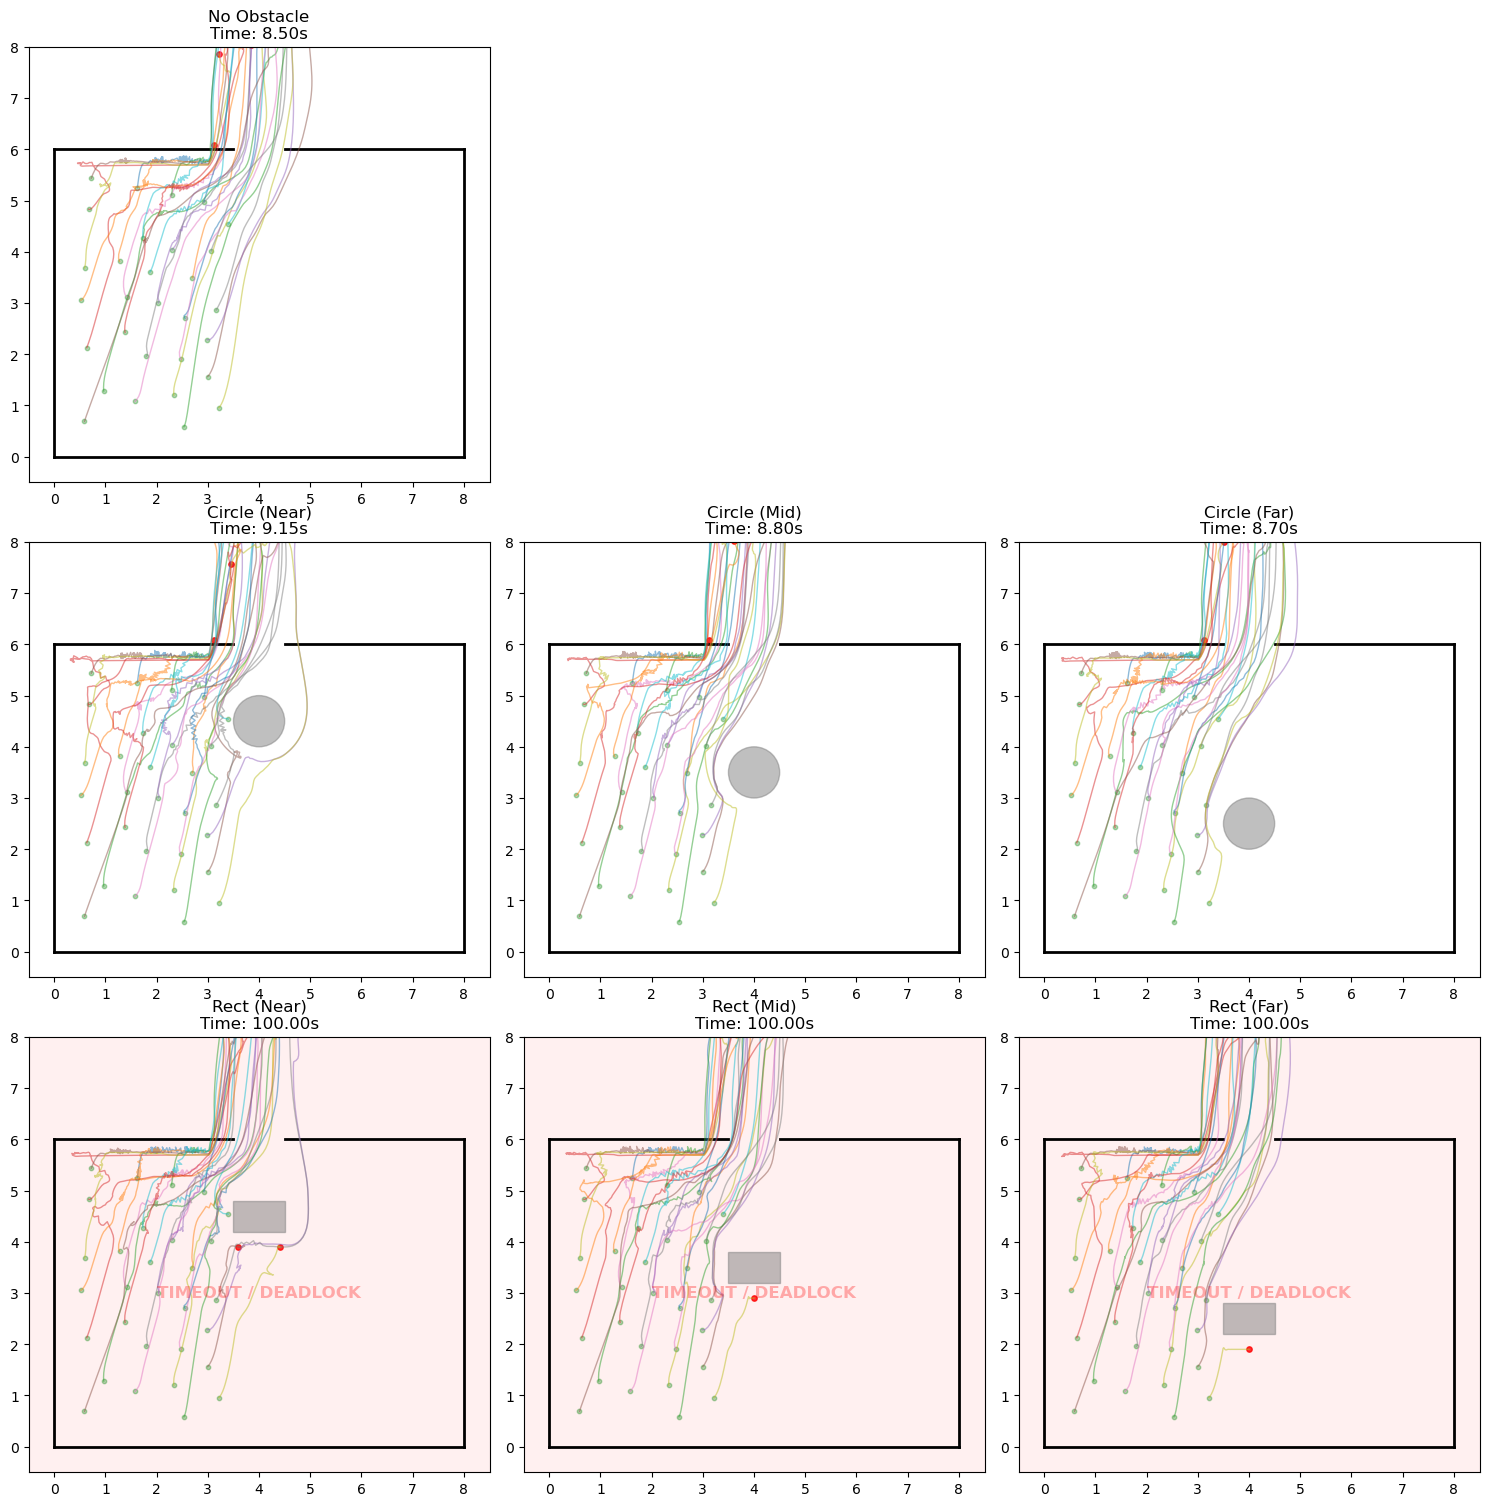

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

grid_mapping = {
    0: (0, 0), # Top-Left (Baseline)
    1: (1, 0), 2: (1, 1), 3: (1, 2), # Middle Row (Circles)
    4: (2, 0), 5: (2, 1), 6: (2, 2)  # Bottom Row (Rects)
}
axes[0, 1].axis('off')
axes[0, 2].axis('off')

# Iterate through our results DataFrame
for idx, row in df_results.iterrows():
    if idx not in grid_mapping:
        continue
        
    r, c = grid_mapping[idx]
    ax = axes[r, c]
    
    scenario_name = row['Scenario']
    time_val = row['Time']
    history = row['History']
    obs_list = row['Obstacles']
    
    trajs = history.transpose(1, 0, 2)
    
    # 1.a Draw Domain Boundaries
    ax.set_xlim(-0.5, 8.5)
    ax.set_ylim(-0.5, 8.0)
    ax.set_aspect('equal')
    
    # 1.b Static Walls
    ax.plot([0, 8], [0, 0], 'k', lw=2) 
    ax.plot([0, 0], [0, 6], 'k', lw=2) 
    ax.plot([8, 8], [0, 6], 'k', lw=2) 
    ax.plot([0, 3.5], [6, 6], 'k', lw=2) 
    ax.plot([4.5, 8], [6, 6], 'k', lw=2) 
    
    # 2. Draw Obstacles
    for obs in obs_list:
        if obs['type'] == 'circle':
            circle = plt.Circle(obs['center'], obs['radius'], color='gray', alpha=0.5)
            ax.add_patch(circle)
        elif obs['type'] == 'rect':
            x_min, x_max = obs['x_range']
            y_min, y_max = obs['y_range']
            width = x_max - x_min
            height = y_max - y_min
            rect = plt.Rectangle((x_min, y_min), width, height, color='gray', alpha=0.5)
            ax.add_patch(rect)

    # 3. Draw Trajectories, where the Red background is for timeout cases
    color_start = 'green'
    color_end = 'red'
    line_alpha = 0.5
    
    if time_val >= 100.0:
        ax.set_facecolor('#fff0f0') 
        ax.text(4, 3, 
            "TIMEOUT / DEADLOCK", 
            color='red', 
            ha='center', 
            va='center', 
            fontsize=12, 
            fontweight='bold', 
            alpha=0.3
        )
    
    for p in trajs:
        ax.plot(p[:, 0], p[:, 1], lw=1, alpha=line_alpha)
        ax.scatter(p[0, 0], p[0, 1], c=color_start, s=10, alpha=0.3)
        ax.scatter(p[-1, 0], p[-1, 1], c=color_end, s=15, alpha=0.8)
        
    ax.set_title(f"{scenario_name}\nTime: {time_val:.2f}s")

plt.tight_layout()
plt.show()